# 🧠 Building a Large Language Model (LLM) From Scratch

This notebook walks you through building a **GPT-style LLM** step by step:

1. **Tokenization** — Convert text to tokens
2. **Dataset Preparation** — Build a training dataset
3. **Model Architecture** — Transformer with multi-head attention
4. **Training Loop** — Train on text data
5. **Text Generation** — Generate new text from the model

> 📌 Based on Andrej Karpathy's [nanoGPT](https://github.com/karpathy/nanoGPT). This is a minimal, educational implementation.

## Step 1: Install & Import Dependencies

In [1]:
# Install dependencies (run once)
!pip install torch --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import time

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


## Step 2: Tokenization

We'll use a simple **character-level tokenizer** — each character maps to an integer.

In [3]:
# Sample training text (you can replace with any text corpus)
text = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub,
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil,
Must give us pause.
""" * 50  # repeat to have more training data

# Build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")
print(f"Characters: {''.join(chars)}")

# Encoder / Decoder
stoi = {ch: i for i, ch in enumerate(chars)}  # char -> int
itos = {i: ch for i, ch in enumerate(chars)}  # int -> char

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Test tokenizer
sample = "To be, or not to be"
encoded = encode(sample)
decoded = decode(encoded)
print(f"\nSample: '{sample}'")
print(f"Encoded: {encoded}")
print(f"Decoded: '{decoded}'")

Vocabulary size: 39 characters
Characters: 
 ',.:;ADFMNOTWabcdefghiklmnopqrstuvwy—

Sample: 'To be, or not to be'
Encoded: [13, 28, 1, 16, 19, 3, 1, 28, 31, 1, 27, 28, 33, 1, 33, 28, 1, 16, 19]
Decoded: 'To be, or not to be'


## Step 3: Dataset Preparation

Split data into **train** and **validation** sets, then create batches.

In [4]:
# Hyperparameters
block_size = 64    # context window (sequence length)
batch_size = 16    # number of sequences per batch
train_split = 0.9  # 90% train, 10% validation

# Encode entire text
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Total tokens: {len(data):,}")

# Train/val split
n = int(train_split * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")

def get_batch(split):
    """Generate a random batch of (input, target) pairs."""
    source = train_data if split == 'train' else val_data
    # Random starting positions
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    # Target is x shifted by 1 (next token prediction)
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# Show a sample batch
xb, yb = get_batch('train')
print(f"\nBatch shape - Input: {xb.shape}, Target: {yb.shape}")
print(f"Sample input (decoded): {repr(decode(xb[0].tolist()[:20]))}")

Total tokens: 27,300
Train tokens: 24,570
Val tokens:   2,730

Batch shape - Input: torch.Size([16, 64]), Target: torch.Size([16, 64])
Sample input (decoded): "her 'tis nobler in t"


## Step 4: Model Architecture — Transformer

We build a **GPT-style decoder-only Transformer** with:
- Token + positional embeddings
- Multi-head causal self-attention
- Feed-forward layers
- Layer normalization

In [5]:
# ── Model Hyperparameters ──────────────────────────────────────────────────────
n_embd   = 128   # embedding dimension
n_head   = 4     # number of attention heads
n_layer  = 4     # number of transformer blocks
dropout  = 0.1   # dropout rate

# ── Single Attention Head ──────────────────────────────────────────────────────
class Head(nn.Module):
    """One head of self-attention."""
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # Causal mask — lower triangular matrix
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        # Scaled dot-product attention
        scale = k.shape[-1] ** -0.5
        wei = q @ k.transpose(-2, -1) * scale  # (B, T, T)
        # Apply causal mask (no peeking at future tokens)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)  # (B, T, head_size)
        return wei @ v     # (B, T, head_size)

# ── Multi-Head Attention ───────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """Multiple attention heads in parallel."""
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

# ── Feed-Forward Network ───────────────────────────────────────────────────────
class FeedForward(nn.Module):
    """Simple MLP with GELU activation."""
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# ── Transformer Block ──────────────────────────────────────────────────────────
class Block(nn.Module):
    """Transformer block: attention + feed-forward with residual connections."""
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa  = MultiHeadAttention(n_head, head_size)  # self-attention
        self.ffwd = FeedForward(n_embd)                   # feed-forward
        self.ln1 = nn.LayerNorm(n_embd)                  # pre-attention norm
        self.ln2 = nn.LayerNorm(n_embd)                  # pre-ffwd norm

    def forward(self, x):
        x = x + self.sa(self.ln1(x))    # residual: attention
        x = x + self.ffwd(self.ln2(x))  # residual: feed-forward
        return x

print("✅ Attention, Multi-Head Attention, FeedForward, and Block classes defined.")

✅ Attention, Multi-Head Attention, FeedForward, and Block classes defined.


In [6]:
# ── Full GPT Model ─────────────────────────────────────────────────────────────
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Token and positional embeddings
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        # Stack of transformer blocks
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        # Final layer norm and output head
        self.ln_f  = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        # Weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        # Token + position embeddings
        tok_emb = self.token_embedding(idx)                              # (B, T, C)
        pos_emb = self.position_embedding(torch.arange(T, device=device)) # (T, C)
        x = tok_emb + pos_emb                                           # (B, T, C)
        # Transformer blocks
        x = self.blocks(x)    # (B, T, C)
        x = self.ln_f(x)      # (B, T, C)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        # Compute loss if targets are provided
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Autoregressively generate tokens."""
        for _ in range(max_new_tokens):
            # Crop to block_size context
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature  # (B, vocab_size)
            # Optional top-k sampling
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1)             # (B, T+1)
        return idx

# Instantiate model
model = GPTLanguageModel().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model created!")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

✅ Model created!
   Total parameters:     810,023
   Trainable parameters: 810,023

Model architecture:
GPTLanguageModel(
  (token_embedding): Embedding(39, 128)
  (position_embedding): Embedding(64, 128)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): D

## Step 5: Training Loop

Train the model using **AdamW optimizer** and monitor loss.

In [7]:
# Training hyperparameters
learning_rate = 3e-4
max_iters     = 3000
eval_interval = 300
eval_iters    = 50

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

@torch.no_grad()
def estimate_loss():
    """Estimate loss on train and val splits."""
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# ── Training ───────────────────────────────────────────────────────────────────
print("Starting training...\n")
train_losses, val_losses = [], []
start_time = time.time()

for iter in range(max_iters):
    # Evaluate periodically
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        elapsed = time.time() - start_time
        print(f"Step {iter:4d}/{max_iters} | "
              f"train loss: {losses['train']:.4f} | "
              f"val loss: {losses['val']:.4f} | "
              f"time: {elapsed:.1f}s")
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())

    # Forward + backward pass
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    # Gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

print("\n✅ Training complete!")

Starting training...

Step    0/3000 | train loss: 3.6602 | val loss: 3.6605 | time: 1.2s
Step  300/3000 | train loss: 0.4645 | val loss: 0.4629 | time: 11.0s
Step  600/3000 | train loss: 0.1159 | val loss: 0.1159 | time: 22.6s
Step  900/3000 | train loss: 0.0865 | val loss: 0.0852 | time: 31.5s
Step 1200/3000 | train loss: 0.0755 | val loss: 0.0752 | time: 40.0s
Step 1500/3000 | train loss: 0.0728 | val loss: 0.0712 | time: 48.6s
Step 1800/3000 | train loss: 0.0659 | val loss: 0.0654 | time: 57.7s
Step 2100/3000 | train loss: 0.0649 | val loss: 0.0662 | time: 67.3s
Step 2400/3000 | train loss: 0.0623 | val loss: 0.0625 | time: 76.1s
Step 2700/3000 | train loss: 0.0645 | val loss: 0.0607 | time: 84.9s
Step 2999/3000 | train loss: 0.0628 | val loss: 0.0643 | time: 93.7s

✅ Training complete!


## Step 6: Visualize Training Loss

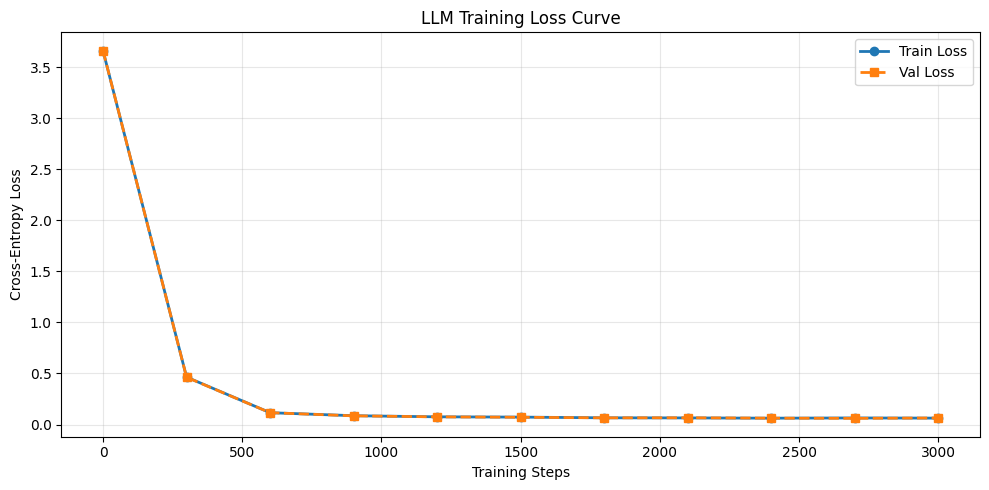

Loss curve saved to training_loss.png


In [8]:
import matplotlib.pyplot as plt

steps = list(range(0, max_iters + 1, eval_interval))
if len(steps) > len(train_losses):
    steps = steps[:len(train_losses)]

plt.figure(figsize=(10, 5))
plt.plot(steps, train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(steps, val_losses,   label='Val Loss',   marker='s', linewidth=2, linestyle='--')
plt.xlabel('Training Steps')
plt.ylabel('Cross-Entropy Loss')
plt.title('LLM Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print("Loss curve saved to training_loss.png")

## Step 7: Text Generation

Use the trained model to **generate new text** autoregressively.

In [9]:
model.eval()

def generate_text(prompt="", max_new_tokens=200, temperature=0.8, top_k=40):
    """Generate text from an optional prompt."""
    if prompt:
        context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    else:
        # Start from a newline character
        context = torch.zeros((1, 1), dtype=torch.long, device=device)

    generated_ids = model.generate(
        context,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k
    )
    return decode(generated_ids[0].tolist())

# Generate with different temperatures
print("=" * 60)
print("GENERATED TEXT (temperature=0.8, creative)")
print("=" * 60)
print(generate_text(max_new_tokens=300, temperature=0.8))

print("\n" + "=" * 60)
print("GENERATED TEXT (temperature=0.3, focused)")
print("=" * 60)
print(generate_text(max_new_tokens=300, temperature=0.3))

GENERATED TEXT (temperature=0.8, creative)

To sleep, perchance to dream—ay, there's the rub,
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil,
Must give us pause.

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to t

GENERATED TEXT (temperature=0.3, focused)

When we have shuffled off this mortal coil,
Must give us pause.

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sl


## Step 8: Save & Load the Model

In [10]:
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': vocab_size,
    'stoi': stoi,
    'itos': itos,
    'hyperparams': {
        'n_embd': n_embd,
        'n_head': n_head,
        'n_layer': n_layer,
        'block_size': block_size,
        'dropout': dropout,
    }
}, 'gpt_model.pt')
print("✅ Model saved to gpt_model.pt")

# Load model
checkpoint = torch.load('gpt_model.pt', map_location=device)
loaded_model = GPTLanguageModel().to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print("✅ Model loaded successfully!")

# Quick test
test_output = decode(loaded_model.generate(
    torch.zeros((1, 1), dtype=torch.long, device=device),
    max_new_tokens=100, temperature=0.8
)[0].tolist())
print(f"\nQuick test output:\n{test_output}")

✅ Model saved to gpt_model.pt
✅ Model loaded successfully!

Quick test output:

Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by


## 🚀 Next Steps — Scale Up

This is a character-level toy model. To build production LLMs:

| Upgrade | How |
|---|---|
| **Better tokenizer** | Use BPE (tiktoken, sentencepiece) instead of char-level |
| **More data** | Train on billions of tokens (Common Crawl, books, code) |
| **Bigger model** | Scale n_embd, n_head, n_layer |
| **Rotary embeddings** | Replace learned position embeddings with RoPE |
| **Flash Attention** | Use `torch.nn.functional.scaled_dot_product_attention` |
| **Distributed training** | Use PyTorch DDP / DeepSpeed for multi-GPU |
| **Fine-tuning** | Apply SFT + RLHF/DPO for instruction-following |

### Recommended Resources
- 📖 [Andrej Karpathy - nanoGPT](https://github.com/karpathy/nanoGPT)
- 📖 [Hugging Face Transformers](https://huggingface.co/docs/transformers)
- 📖 [The Annotated Transformer](http://nlp.seas.harvard.edu/annotated-transformer/)
- 📖 [Llama 3 Technical Report](https://ai.meta.com/research/publications/)